# Script for the forthcoming article on Probability and Monte Carlo Simulations

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

ModuleNotFoundError: No module named 'pandas'

## Card Collector Problem

In [2]:
def Collection(n):
    return n
    

## Simpsons Paradox

## Berksons Paradox

Text(0, 0.5, 'Character')

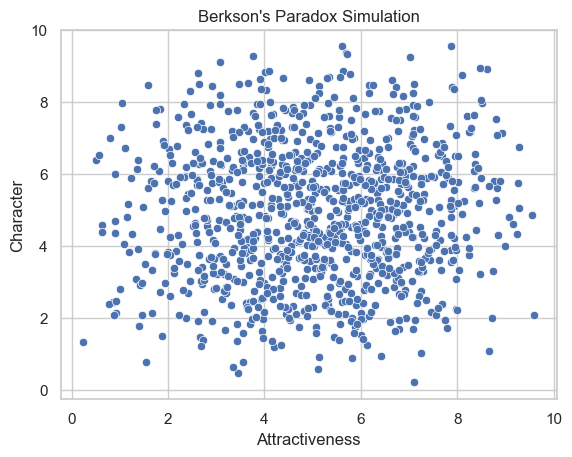

In [18]:
# Set Paramenters

n = 1000
alpha = 3
beta = 3

# Simulate Data
attractiveness = np.random.beta(alpha, beta, n)
attractiveness = attractiveness * 10

character = np.random.beta(alpha, beta, n)
character = character * 10

# Create DataFrame
berksons_df = pd.DataFrame({
    'attractiveness': attractiveness,
    'character': character
})

# Plot the Data
sns.scatterplot(data=berksons_df, x='attractiveness', y='character')
plt.title("Berkson's Paradox Simulation")
plt.xlabel("Attractiveness")
plt.ylabel("Character")


In [19]:
# Regress character on attractiveness to show that there is no correlation
import statsmodels.api as sm

# Add intercept
X_with_const = sm.add_constant(berksons_df[['attractiveness']])

# determine dependent variable (doesnt matter here)
y = berksons_df['character']

# fit OLS
sm_model = sm.OLS(y, X_with_const).fit()

# 3. Print the results (includes Coeff, P-values, and 95% Conf. Intervals)
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:              character   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.778
Date:                 So, 15 Mär 2026   Prob (F-statistic):             0.0959
Time:                        21:24:15   Log-Likelihood:                -2041.8
No. Observations:                1000   AIC:                             4088.
Df Residuals:                     998   BIC:                             4097.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              4.6451      0.169     27.

In [20]:
# Add a selection bias where the sum of attractiveness and character is >14
berksons_df["bias"] = (berksons_df['attractiveness'] + berksons_df['character']) > 14

In [21]:
selected_group = berksons_df[berksons_df["bias"] == True]

X = sm.add_constant(selected_group['attractiveness'])
y = selected_group['character']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              character   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.451
Method:                 Least Squares   F-statistic:                     63.46
Date:                 So, 15 Mär 2026   Prob (F-statistic):           1.38e-11
Time:                        21:24:15   Log-Likelihood:                -94.555
No. Observations:                  77   AIC:                             193.1
Df Residuals:                      75   BIC:                             197.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             13.0496      0.713     18.

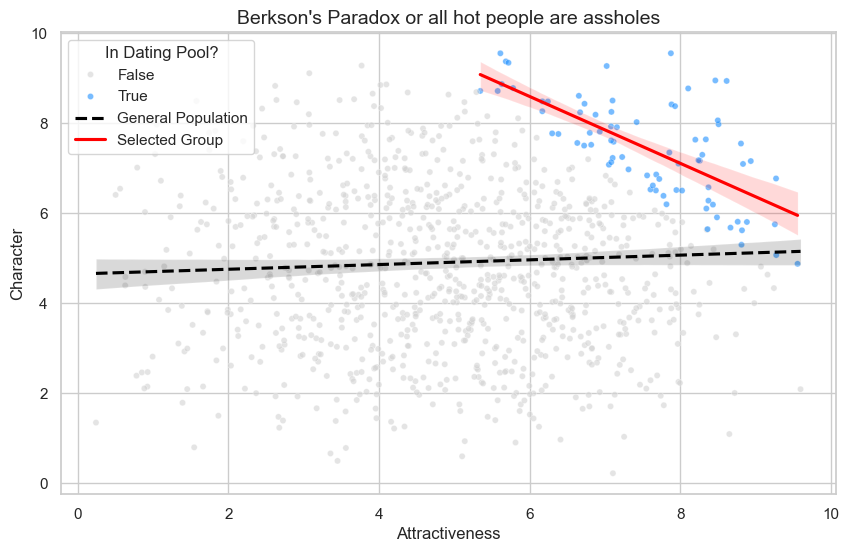

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot  points colored by the bias column
sns.scatterplot(data=berksons_df, x='attractiveness', y='character', 
                hue='bias', palette={True: 'dodgerblue', False: 'lightgray'}, 
                alpha=0.6, s=20)

# Regression Line for full pop
sns.regplot(data=berksons_df, x='attractiveness', y='character', 
            scatter=False, color='black', label='General Population',
            line_kws={"linestyle": "--"})

#Regression Line for selected group
sns.regplot(data=berksons_df[berksons_df['bias'] == True], 
            x='attractiveness', y='character', 
            scatter=False, color='red', label='Selected Group')

#Formatting
plt.title("Berkson's Paradox or all hot people are assholes", fontsize=14)
plt.xlabel("Attractiveness")
plt.ylabel("Character")
plt.legend(title="In Dating Pool?")
plt.show()